# ImplicitRadialGyroid — Python reimplementation via pythonnet
IMPORTANT: CHOOSE THE LEAP71 INTERPRETER: in the upper right corner of this iPython window you can select the interpreter


This notebook reproduces the `RadialTask` example originally in
`LEAP71_LatticeLibrary-main/Examples/Ex_ImplicitLibraryRadialTask.cs`
in pure Python, calling the C# functions through the bindings in `leap71_bindings.py`.

**Structure**

| Cell | What it does |
|------|-------------|
| 1 | Imports & path setup |
| 2 | Build geometry: bounding pipe → implicit gyroid → intersection |
| 3 | Run the construction (toggle `HEADLESS` here) |
| 4 | Load & visualise the resulting VDB |

> **Prerequisite:** build the C# project before running —
> `cd PicoGK_Examples-main && dotnet build`

## Cell 1 — Imports

In [1]:
import os
import sys
from pathlib import Path

# ── set up X11 display environment for graphical windows ──────────────────
os.environ.setdefault('DISPLAY', ':2')
xdg_dir = f'/tmp/xdg-runtime-{os.getuid()}'
os.makedirs(xdg_dir, mode=0o700, exist_ok=True)
os.environ['XDG_RUNTIME_DIR'] = xdg_dir
os.environ.setdefault('GDK_BACKEND', 'x11')
os.environ.setdefault('LIBGL_ALWAYS_SOFTWARE', '1')
os.environ['MESA_LOADER_DRIVER_OVERRIDE'] = 'swr,llvmpipe'
os.environ['MESA_SHADER_CACHE'] = 'false'
os.environ['MESA_SHADER_CACHE_DIR'] = ''
os.environ['ZSTD_NBTHREADS'] = '1'

# ── locate leap71_bindings.py (one directory above notebooks/) ────────────
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'leap71_bindings.py').exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'leap71_bindings.py').exists():
    raise FileNotFoundError('Cannot find leap71_bindings.py – run this notebook from the repo root')
sys.path.insert(0, str(REPO_ROOT))

import leap71_bindings as leap71

# ── pull the most-used names into this namespace for readability ──────────
from leap71_bindings import (
    Single, Library,
    LocalFrame, BasePipe,
    Sh, Cp,
    EExport,
    export_voxels_to_vdb, run_in_library,
)

# ── LatticeLibrary implicit pattern (not re-exported from leap71_bindings) ─
from Leap71.LatticeLibrary import ImplicitRadialGyroid

OUTPUT_DIR = REPO_ROOT / 'Examples'
OUTPUT_DIR.mkdir(exist_ok=True)
vdb_PATH   = OUTPUT_DIR / 'ImplicitRadialGyroid_Python.vdb'

print('Bindings loaded successfully.')
print(f'Output will be written to: {OUTPUT_DIR}')

Bindings loaded successfully.
Output will be written to: /workspace/LEAP71_version_KBE/Examples


## Cell 2 — Geometry construction function

Direct translation of `RadialTask()` from `Ex_ImplicitLibraryRadialTask.cs`:

| Step | C# | Python |
|------|----|--------|
| 1 | `BasePipe(new LocalFrame(), 50, 20, 50)` → `oConstructVoxels()` | same via `BasePipe` + `.oConstructVoxels()` |
| 2 | `ImplicitRadialGyroid(16, 10f, 0.5f)` | same via `ImplicitRadialGyroid` |
| 3 | `voxBounding.voxIntersectImplicit(pattern)` | `Sh.voxIntersectImplicit(vox_bounding, pattern)` |
| 4 | `Sh.PreviewVoxels(...)` | same (no-op in headless mode) |

In [2]:
def build_radial_gyroid(output_dir: Path, headless: bool = True):
    """Translate of RadialTask() from Ex_ImplicitLibraryRadialTask.cs."""

    def preview(vox, colour=Cp.strRock, alpha=1.0):
        if not headless:
            Sh.PreviewVoxels(vox, colour, Single(alpha))

    # Step 1: define bounding object
    # BasePipe(frame, length=50, innerRadius=20, outerRadius=50)
    print('  constructing bounding pipe …')
    o_pipe      = BasePipe(LocalFrame(), 50, 20, 50)
    vox_bounding = o_pipe.oConstructVoxels()

    # Step 2: define the ImplicitRadialGyroid pattern
    # ImplicitRadialGyroid(nUnitsPerRound=16, fUnitSizeInZ=10, fWallThickness=0.5)
    f_unit_size       = 10.0
    f_wall_thickness  = 0.5
    n_samples_per_round = 16
    print('  setting up ImplicitRadialGyroid pattern …')
    implicit_pattern = ImplicitRadialGyroid(
        n_samples_per_round,
        Single(f_unit_size),
        Single(f_wall_thickness),
    )

    # Step 3: generate final implicit geometry
    # voxIntersectImplicit is a C# extension method on Voxels exposed via Sh
    print('  intersecting bounding voxels with implicit gyroid …')
    vox_implicit = Sh.voxIntersectImplicit(vox_bounding, implicit_pattern)

    # Step 4: visualisation (skipped in headless mode)
    str_color = Cp.strRandom()
    preview(vox_implicit, str_color)
    preview(vox_bounding, str_color, 0.3)

    # Export
    vdb_path = str(output_dir / 'ImplicitRadialGyroid_Python.vdb')
    print(f'  exporting vdb → {vdb_path}')
    export_voxels_to_vdb(vox_implicit, vdb_path)

    print('Finished Task successfully.')
    return vox_implicit


print('build_radial_gyroid() defined.')

build_radial_gyroid() defined.


## Cell 3 — Run the construction

Toggle **`HEADLESS`** to control the viewer:

| `HEADLESS` | Behaviour |
|---|---|
| `True` (default) | No window opens. Fast, notebook-friendly. `PreviewVoxels` calls are skipped. |
| `False` | The PicoGK viewer window opens, geometry is previewed (mirrors the original C# experience). `Library.Go` blocks until the window is closed. |

In [3]:
import time

# ── toggle this to open the interactive PicoGK viewer ─────────────────────
HEADLESS   = False    # False → viewer window with step-by-step previews
VOXEL_SIZE = 0.5     # mm – match the original example

t0 = time.time()
mode_label = 'headless' if HEADLESS else 'with viewer'
print(f'Starting construction  (voxel size = {VOXEL_SIZE} mm, mode = {mode_label}) …')

def _task():
    build_radial_gyroid(OUTPUT_DIR, headless=HEADLESS)

run_in_library(_task, voxel_size=VOXEL_SIZE, output_dir=OUTPUT_DIR, headless=HEADLESS)

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f} s')
print(f'vdb written to: {vdb_PATH}')

Starting construction  (voxel size = 0.5 mm, mode = with viewer) …
      0s    0.0+ Opened /workspace/LEAP71_version_KBE/Examples/PicoGK.log
      0s    0.0+ 
      0s    0.0+ ----------------------------------------
      0s    0.0+ 
      0s    0.0+ Current time (UTC): 2026-04-30 21:51:41 (UTC)
      0s    0.0+ Current local time: 2026-04-30 21:51:41 (+00:00)
      0s    0.0+ 
      0s    0.0+ ----------------------------------------
      0s    0.0+ 
      0s    0.0+ System Info:
      0s    0.0+ 
      0s    0.0+ Machine Name:         78094785f08f
      0s    0.0+ Operating System      Ubuntu 24.04.4 LTS
      0s    0.0+ Version:              Unix 6.6.87.2
      0s    0.0+ OS Architecture:      X64
      0s    0.0+ Proc Architecture:    X64
      0s    0.0+ 64 Bit OS:            Yes
      0s    0.0+ 64 Bit Process:       Yes
      0s    0.0+ Processor Count:      20
      0s    0.0+ Working Set:          155MB
      0s    0.0+ C# Framework:         .NET 9.0.15
      0s    0.0+ C# C

Failed to create /mesa_shader_cache for shader cache (Permission denied)---disabling.


      1s    0.6+ PicoGK:    PicoGK Core Library
      1s    0.0+            1.7.1
      1s    0.0+            2024-08-03 18:24:24 picogk
      1s    0.0+ 
      1s    0.0+ VoxelSize: 0.5 (mm)
      1s    0.0+ Happy Computational Engineering!
      1s    0.0+ 
      1s    0.0+ 
      1s    0.0+ Loading lights embedded environment
      1s    0.0+ Starting tasks.
      1s    0.0+ 
  constructing bounding pipe …
      1s    0.0+ Loading Lights
  setting up ImplicitRadialGyroid pattern …
  intersecting bounding voxels with implicit gyroid …
  exporting vdb → /workspace/LEAP71_version_KBE/Examples/ImplicitRadialGyroid_Python.vdb
Finished Task successfully.
     13s   12.1+ Viewer Window Closed
     13s    0.0+ 
     13s    0.0+ ----------------------------------------
     13s    0.0+ 
     13s    0.0+ Closing log file.
     13s    0.0+ Current time (UTC): 2026-04-30 21:51:53 (UTC)
     13s    0.0+ Current local time: 2026-04-30 21:51:53 (+00:00)
     13s    0.0+ Done.
Done in 12.8 s
vdb wr

## Cell 4 — Visualise the vdb with PyVista

PyVista backends for Jupyter:

| Backend | Install | Notes |
|---|---|---|
| `trame` | `pip install pyvista[jupyter]` | Interactive (rotate/zoom) in VS Code |
| `static` | `pip install pyvista` | Static PNG, always works |

Set `PYVISTA_BACKEND` in the cell below to switch.

Reading /workspace/LEAP71_version_KBE/Examples/ImplicitRadialGyroid_Python.vdb …
  shape (Z,Y,X) : (105, 205, 205)
  voxel size    : 1.0 mm
  bounding box  : X [-102, 103]  Y [-102, 103]  Z [-2, 103] mm
Extracting isosurface …
  raw  : 1,163,770 vertices, 2,335,092 triangles
  decimated: 246,225 vertices, 500,000 triangles


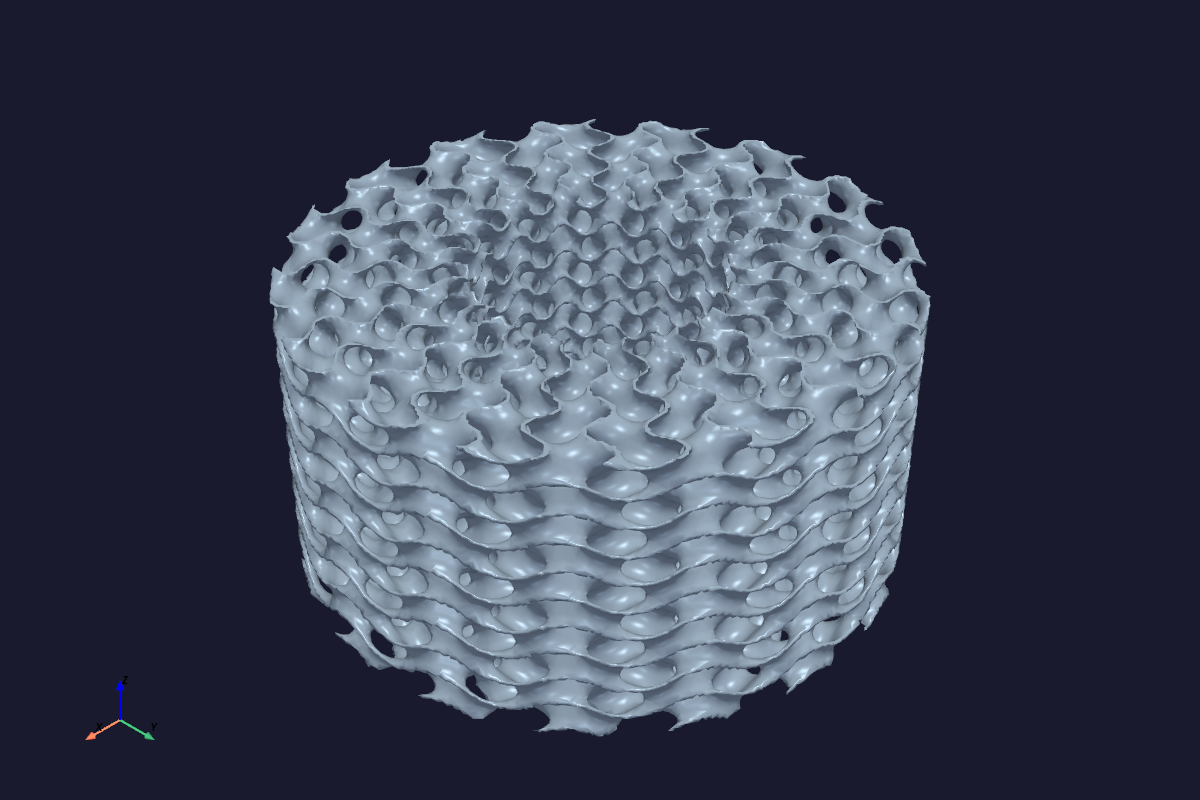

In [5]:
try:
    import pyvista as pv
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "pyvista not found — install with:  pip install 'pyvista[jupyter]'"
    ) from exc

import os, sys
import numpy as np

os.environ['MESA_SHADER_CACHE_DISABLE'] = '1'

# ── make vdb_numpy importable ──────────────────────────────────────────────
VDB_READER_DIR = REPO_ROOT / 'vdb_reader'
if str(VDB_READER_DIR) not in sys.path:
    sys.path.insert(0, str(VDB_READER_DIR))

try:
    import vdb_numpy
except ImportError as exc:
    raise ImportError(
        f"vdb_numpy extension not found in {VDB_READER_DIR}. "
        "Build it first:\n"
        f"  cd {VDB_READER_DIR} && python setup.py build_ext --inplace"
    ) from exc

# 'static'  → offline PNG embedded in the cell (always works, no WebGL needed)
# 'trame'   → interactive rotate/zoom (requires working WebGL in VS Code webview)
PYVISTA_BACKEND = 'static'
pv.set_jupyter_backend(PYVISTA_BACKEND)
pv.global_theme.allow_empty_mesh = True

if not vdb_PATH.exists():
    raise FileNotFoundError(
        f'VDB not found: {vdb_PATH}\nRun Cell 3 first to generate it.'
    )

# ── load VDB → dense numpy array ──────────────────────────────────────────
print(f'Reading {vdb_PATH} …')
arr, origin, voxel_size = vdb_numpy.read_vdb_as_numpy(str(vdb_PATH))
nz, ny, nx = arr.shape
ox, oy, oz = origin
print(f'  shape (Z,Y,X) : {arr.shape}')
print(f'  voxel size    : {voxel_size} mm')
print(f'  bounding box  : '
      f'X [{ox:.0f}, {ox+nx*voxel_size:.0f}]  '
      f'Y [{oy:.0f}, {oy+ny*voxel_size:.0f}]  '
      f'Z [{oz:.0f}, {oz+nz*voxel_size:.0f}] mm')

# ── build PyVista ImageData from the SDF volume ───────────────────────────
grid = pv.ImageData(
    dimensions=(nx, ny, nz),
    spacing=(voxel_size, voxel_size, voxel_size),
    origin=(ox, oy, oz),
)
grid.point_data['sdf'] = arr.flatten()

# ── extract iso-surface at sdf == 0, then decimate for fast rendering ─────
print('Extracting isosurface …')
surface = grid.contour([0.0], scalars='sdf')
print(f'  raw  : {surface.n_points:,} vertices, {surface.n_cells:,} triangles')

target_ratio = min(1.0, 500_000 / max(surface.n_cells, 1))
if target_ratio < 1.0:
    surface = surface.decimate(1.0 - target_ratio)
    print(f'  decimated: {surface.n_points:,} vertices, {surface.n_cells:,} triangles')

# ── render ────────────────────────────────────────────────────────────────
pl = pv.Plotter(notebook=True, off_screen=True, window_size=(1200, 800))
pl.set_background('#1a1a2e')
pl.add_mesh(
    surface,
    color='#8ca0b8',
    smooth_shading=True,
    specular=0.6,
    specular_power=30,
    ambient=0.2,
)
pl.add_axes(label_size=(0.04, 0.04))
pl.camera_position = 'iso'
pl.camera.zoom(1.2)
pl.show()